# Baseline Return-Risk Models

## Notebook purpose

This notebook trains and evaluates two baseline models:

1. Logistic Regression
2. Multinomial Naive Bayes
3. The purpose is to establish benchmark performance before testing tree-based models such as Random Forest, XGBoost, and CatBoost.


# Import Important Libraries 

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 150)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

print(f"Current Directory: {CURRENT_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_DIR}")
print(f"Processed Data Directory: {PROCESSED_DIR}")

Current Directory: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\notebooks
Project root: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics
Data Directory: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\data
Processed Data Directory: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\data\processed


# Load Final Training Dataset

In [4]:
training_df = pd.read_csv(
    PROCESSED_DIR / "return_risk_training_data.csv"
)

training_df["order_timestamp"] = pd.to_datetime(
    training_df["order_timestamp"],
    errors="coerce"
)

print(f"Rows: {len(training_df):,}")
print(f"Columns: {training_df.shape[1]:,}")
print(
    "Date range: "
    f"{training_df['order_timestamp'].min()} to "
    f"{training_df['order_timestamp'].max()}"
)

Rows: 123,021
Columns: 60
Date range: 2021-01-01 00:01:30 to 2025-12-31 23:58:53


# Validate Target And Leakage Safety


In [5]:
forbidden_columns = [
    "order_status",
    "return_status",
    "return_reason",
    "delivery_days",
    "delivery_status",
    "customer_rating",
    "review_sentiment",
    "customer_review",
    "payment_status",
    "loyalty_points_earned",
    "loyalty_points_redeemed",
]

present_forbidden_columns = [
    column
    for column in forbidden_columns
    if column in training_df.columns
]

print("Target distribution:")
display(
    training_df["return_label"]
    .value_counts()
    .rename_axis("return_label")
    .reset_index(name="order_count")
)

assert set(training_df["return_label"].unique()) == {0, 1}
assert len(present_forbidden_columns) == 0, (
    f"Leakage columns found: {present_forbidden_columns}"
)

print("Target and leakage validation passed.")

Target distribution:


,return_label,order_count
0,0,113559
1,1,9462


Target and leakage validation passed.


# Create Chronological Train, Validation, And Test Sets

In [6]:
train_end_date = pd.Timestamp("2024-12-31 23:59:59")
validation_start_date = pd.Timestamp("2025-01-01")
validation_end_date = pd.Timestamp("2025-06-30 23:59:59")
test_start_date = pd.Timestamp("2025-07-01")

train_df = training_df[
    training_df["order_timestamp"] <= train_end_date
].copy()

validation_df = training_df[
    (training_df["order_timestamp"] >= validation_start_date)
    & (training_df["order_timestamp"] <= validation_end_date)
].copy()

test_df = training_df[
    training_df["order_timestamp"] >= test_start_date
].copy()

split_summary = pd.DataFrame([
    {
        "split": "Train",
        "rows": len(train_df),
        "start_date": train_df["order_timestamp"].min(),
        "end_date": train_df["order_timestamp"].max(),
        "return_rate_percent": train_df["return_label"].mean() * 100,
    },
    {
        "split": "Validation",
        "rows": len(validation_df),
        "start_date": validation_df["order_timestamp"].min(),
        "end_date": validation_df["order_timestamp"].max(),
        "return_rate_percent": validation_df["return_label"].mean() * 100,
    },
    {
        "split": "Test",
        "rows": len(test_df),
        "start_date": test_df["order_timestamp"].min(),
        "end_date": test_df["order_timestamp"].max(),
        "return_rate_percent": test_df["return_label"].mean() * 100,
    },
])

display(split_summary)

,split,rows,start_date,end_date,return_rate_percent
0,Train,98376,2021-01-01 00:01:30,2024-12-31 23:59:06,7.6136
1,Validation,10666,2025-01-01 00:15:26,2025-06-30 23:38:51,8.3443
2,Test,13979,2025-07-01 00:02:13,2025-12-31 23:58:53,7.7402


# Select Target And Model Features

In [7]:
target_column = "return_label"

non_feature_columns = [
    "order_id",
    "customer_id",
    "order_timestamp",
    "order_timestamp_customer",
    target_column,
]

feature_columns = [
    column
    for column in training_df.columns
    if column not in non_feature_columns
]

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_validation = validation_df[feature_columns].copy()
y_validation = validation_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print(f"Number of features: {len(feature_columns)}")
print(f"Categorical features: {len(categorical_columns)}")
print(f"Numeric features: {len(numeric_columns)}")

print("\nCategorical columns:")
print(categorical_columns)

Number of features: 55
Categorical features: 14
Numeric features: 41

Categorical columns:
['sales_channel', 'payment_method', 'currency', 'shipping_method', 'warehouse', 'marketing_channel', 'campaign_name', 'coupon_code', 'gender', 'customer_segment', 'customer_state', 'customer_country', 'region', 'dominant_product_category']


# Create Preprocessing Pipelines

In [8]:
logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler(with_mean=False)),
            ]),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="constant",
                        fill_value="Unknown"
                    ),
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    ),
                ),
            ]),
            categorical_columns,
        ),
    ]
)

naive_bayes_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", MinMaxScaler()),
            ]),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="constant",
                        fill_value="Unknown"
                    ),
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    ),
                ),
            ]),
            categorical_columns,
        ),
    ]
)

# Define Baseline Models

In [9]:
logistic_model = Pipeline([
    ("preprocessor", logistic_preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="saga",
            random_state=42,
        ),
    ),
])

naive_bayes_model = Pipeline([
    ("preprocessor", naive_bayes_preprocessor),
    (
        "model",
        MultinomialNB(alpha=1.0),
    ),
])

# Create A Reusable Validation Function

In [10]:
def evaluate_model_on_validation(
    model_name,
    model_pipeline,
    X_train,
    y_train,
    X_validation,
    y_validation,
):
    model_pipeline.fit(X_train, y_train)

    validation_probabilities = model_pipeline.predict_proba(
        X_validation
    )[:, 1]

    threshold_rows = []

    for threshold in np.arange(0.05, 0.96, 0.05):
        predictions = (
            validation_probabilities >= threshold
        ).astype(int)

        threshold_rows.append({
            "threshold": round(float(threshold), 2),
            "precision": precision_score(
                y_validation,
                predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_validation,
                predictions,
                zero_division=0,
            ),
            "f1_score": f1_score(
                y_validation,
                predictions,
                zero_division=0,
            ),
        })

    threshold_results_df = pd.DataFrame(threshold_rows)

    best_threshold_row = threshold_results_df.loc[
        threshold_results_df["f1_score"].idxmax()
    ]

    best_threshold = best_threshold_row["threshold"]

    final_predictions = (
        validation_probabilities >= best_threshold
    ).astype(int)

    model_result = {
        "model": model_name,
        "pr_auc": average_precision_score(
            y_validation,
            validation_probabilities,
        ),
        "roc_auc": roc_auc_score(
            y_validation,
            validation_probabilities,
        ),
        "best_threshold": best_threshold,
        "precision": precision_score(
            y_validation,
            final_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_validation,
            final_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_validation,
            final_predictions,
            zero_division=0,
        ),
    }

    return (
        model_pipeline,
        validation_probabilities,
        final_predictions,
        threshold_results_df,
        model_result,
    )

# Train And Evaluate Logistic Regression

In [11]:
(
    trained_logistic_model,
    logistic_validation_probabilities,
    logistic_validation_predictions,
    logistic_threshold_results,
    logistic_result,
) = evaluate_model_on_validation(
    model_name="Logistic Regression",
    model_pipeline=logistic_model,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

display(pd.DataFrame([logistic_result]))
display(logistic_threshold_results)

,model,pr_auc,roc_auc,best_threshold,precision,recall,f1_score
0,Logistic Regression,0.8606,0.9856,0.8500,0.8254,0.9191,0.8698


,threshold,precision,recall,f1_score
0,0.0500,0.2603,0.9888,0.4121
1,0.1000,0.3107,0.9876,0.4727
2,0.1500,0.3522,0.9854,0.5189
3,0.2000,0.3877,0.9831,0.5561
4,0.2500,0.4193,0.9831,0.5878
5,0.3000,0.4524,0.9820,0.6194
6,0.3500,0.4747,0.9820,0.6401
7,0.4000,0.5003,0.9809,0.6626
8,0.4500,0.5307,0.9809,0.6888
9,0.5000,0.5602,0.9775,0.7122


# Train And Evaluate Multinomial Naive Bayes

In [12]:
(
    trained_naive_bayes_model,
    naive_bayes_validation_probabilities,
    naive_bayes_validation_predictions,
    naive_bayes_threshold_results,
    naive_bayes_result,
) = evaluate_model_on_validation(
    model_name="Multinomial Naive Bayes",
    model_pipeline=naive_bayes_model,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

display(pd.DataFrame([naive_bayes_result]))
display(naive_bayes_threshold_results)

,model,pr_auc,roc_auc,best_threshold,precision,recall,f1_score
0,Multinomial Naive Bayes,0.8258,0.9653,0.1500,0.8402,0.7382,0.7859


,threshold,precision,recall,f1_score
0,0.0500,0.2727,0.9652,0.4252
1,0.1000,0.5910,0.9337,0.7239
2,0.1500,0.8402,0.7382,0.7859
3,0.2000,0.9313,0.1371,0.2390
4,0.2500,0.9444,0.0191,0.0374
5,0.3000,0.0000,0.0000,0.0000
6,0.3500,0.0000,0.0000,0.0000
7,0.4000,0.0000,0.0000,0.0000
8,0.4500,0.0000,0.0000,0.0000
9,0.5000,0.0000,0.0000,0.0000


# Compare Baseline Models

In [13]:
baseline_results_df = pd.DataFrame([
    logistic_result,
    naive_bayes_result,
]).sort_values(
    "pr_auc",
    ascending=False,
)

display(baseline_results_df)

,model,pr_auc,roc_auc,best_threshold,precision,recall,f1_score
0,Logistic Regression,0.8606,0.9856,0.8500,0.8254,0.9191,0.8698
1,Multinomial Naive Bayes,0.8258,0.9653,0.1500,0.8402,0.7382,0.7859


# Visualize Validation Performance


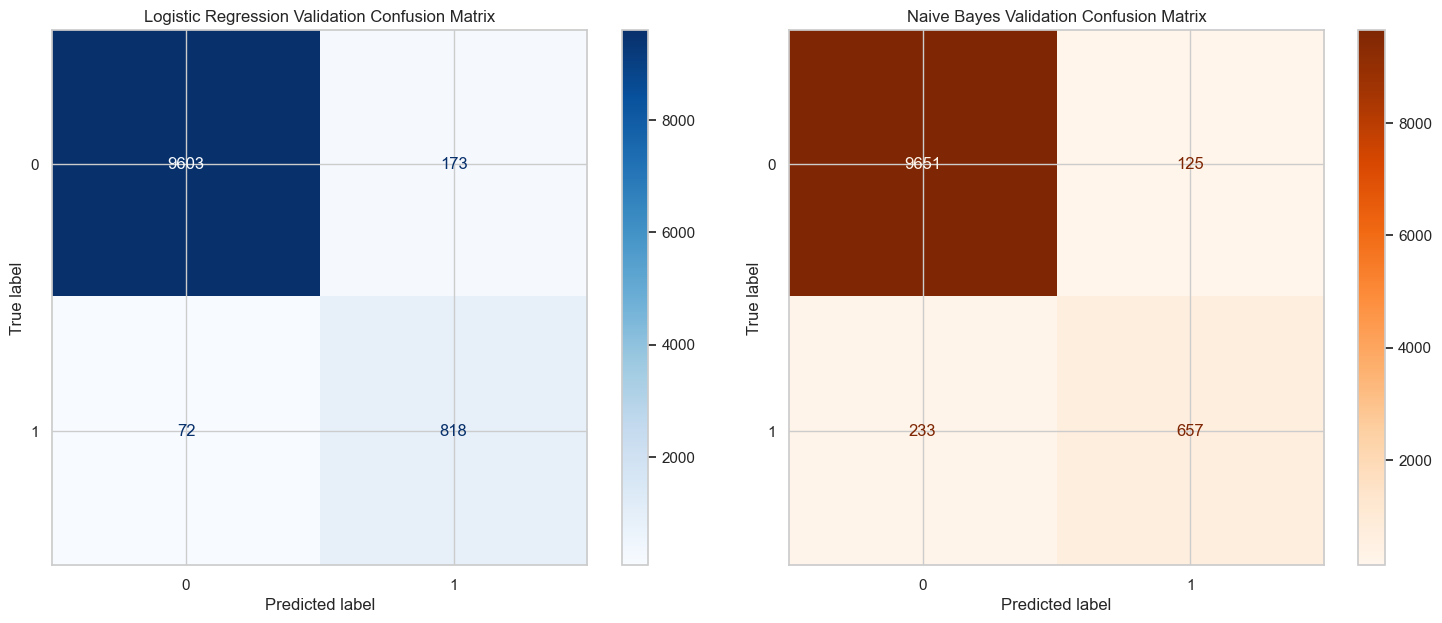

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    logistic_validation_predictions,
    ax=axes[0],
    cmap="Blues",
)
axes[0].set_title("Logistic Regression Validation Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    naive_bayes_validation_predictions,
    ax=axes[1],
    cmap="Oranges",
)
axes[1].set_title("Naive Bayes Validation Confusion Matrix")

plt.tight_layout()
plt.show()

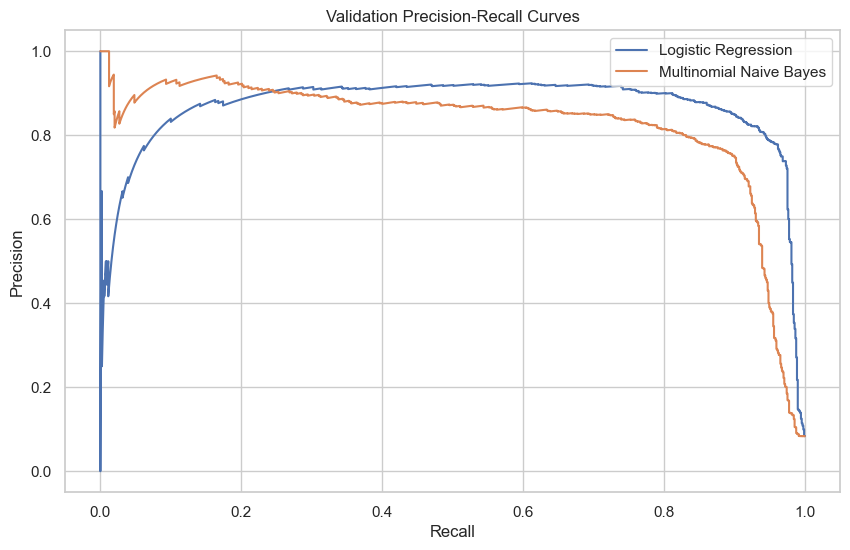

In [15]:
logistic_precision, logistic_recall, _ = precision_recall_curve(
    y_validation,
    logistic_validation_probabilities,
)

naive_precision, naive_recall, _ = precision_recall_curve(
    y_validation,
    naive_bayes_validation_probabilities,
)

plt.figure(figsize=(10, 6))

plt.plot(
    logistic_recall,
    logistic_precision,
    label="Logistic Regression",
)

plt.plot(
    naive_recall,
    naive_precision,
    label="Multinomial Naive Bayes",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curves")
plt.legend()
plt.show()

# Save Baseline Validation Results


In [16]:
baseline_results_path = (
    PROCESSED_DIR / "baseline_model_validation_results.csv"
)

baseline_results_df.to_csv(
    baseline_results_path,
    index=False,
)

print(f"Saved baseline results to: {baseline_results_path}")

Saved baseline results to: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\data\processed\baseline_model_validation_results.csv
